In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

+----+-------------------+------------------+
|    | Column            |   Missing Values |
|----+-------------------+------------------|
|  0 | Age               |                0 |
|  1 | Gender            |                0 |
|  2 | Height_cm         |             3434 |
|  3 | Weight_kg         |             3179 |
|  4 | Waist_cm          |             3743 |
|  5 | Hip_cm            |             5157 |
|  6 | Systolic_BP       |             4416 |
|  7 | Diastolic_BP      |             4416 |
|  8 | HbA1c             |             5218 |
|  9 | FBS               |             8261 |
| 10 | Cholesterol_Total |             5043 |
| 11 | HDL               |             5043 |
| 12 | Diabetes_Status   |              481 |
+----+-------------------+------------------+
Age                  0
Gender               0
Height_cm            0
Weight_kg            0
Waist_cm             0
Hip_cm               0
Systolic_BP          0
Diastolic_BP         0
HbA1c                0
FBS        

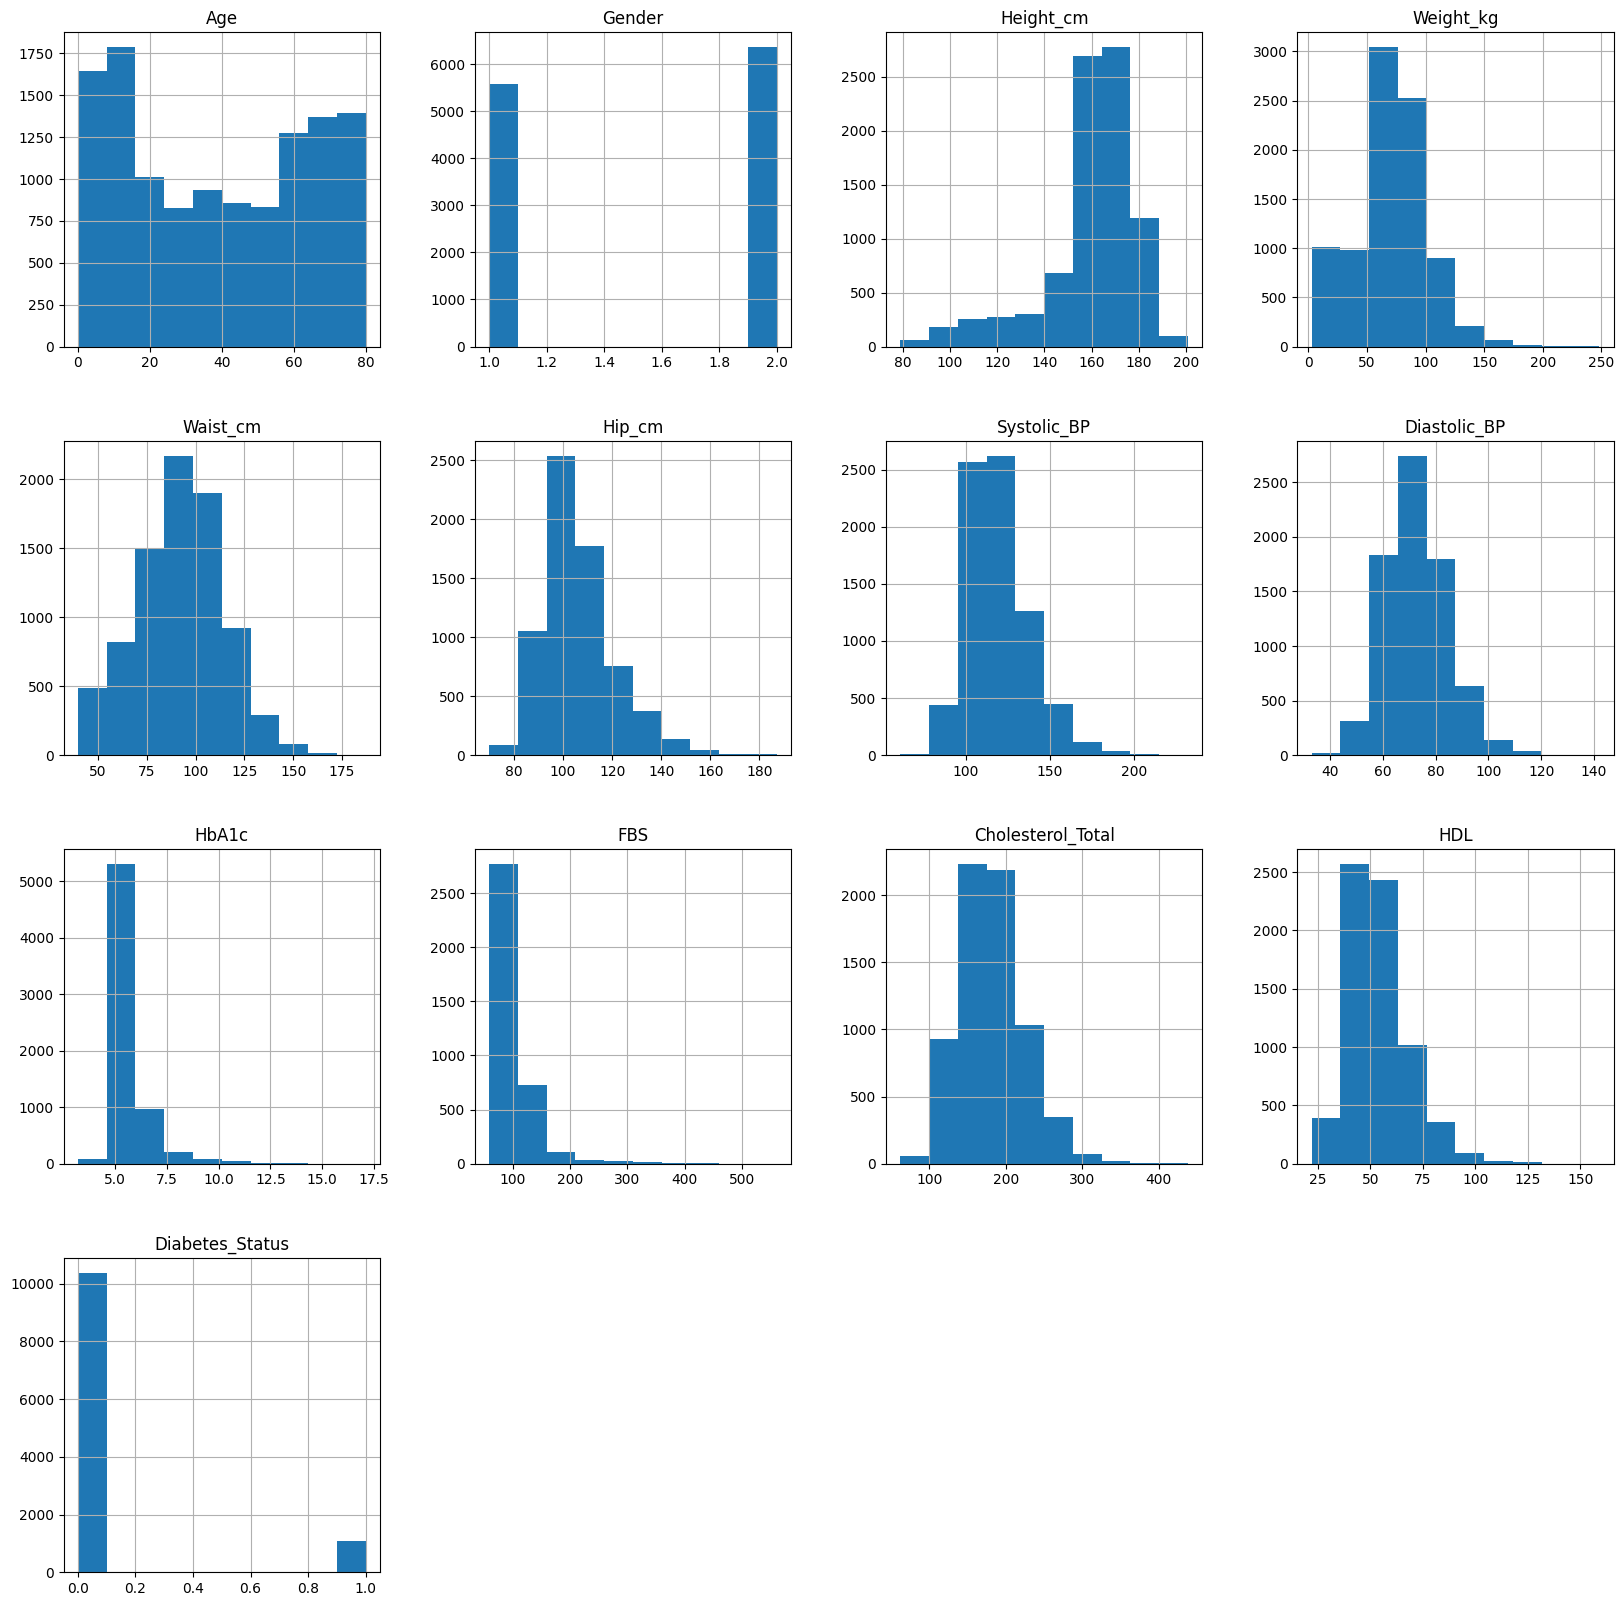

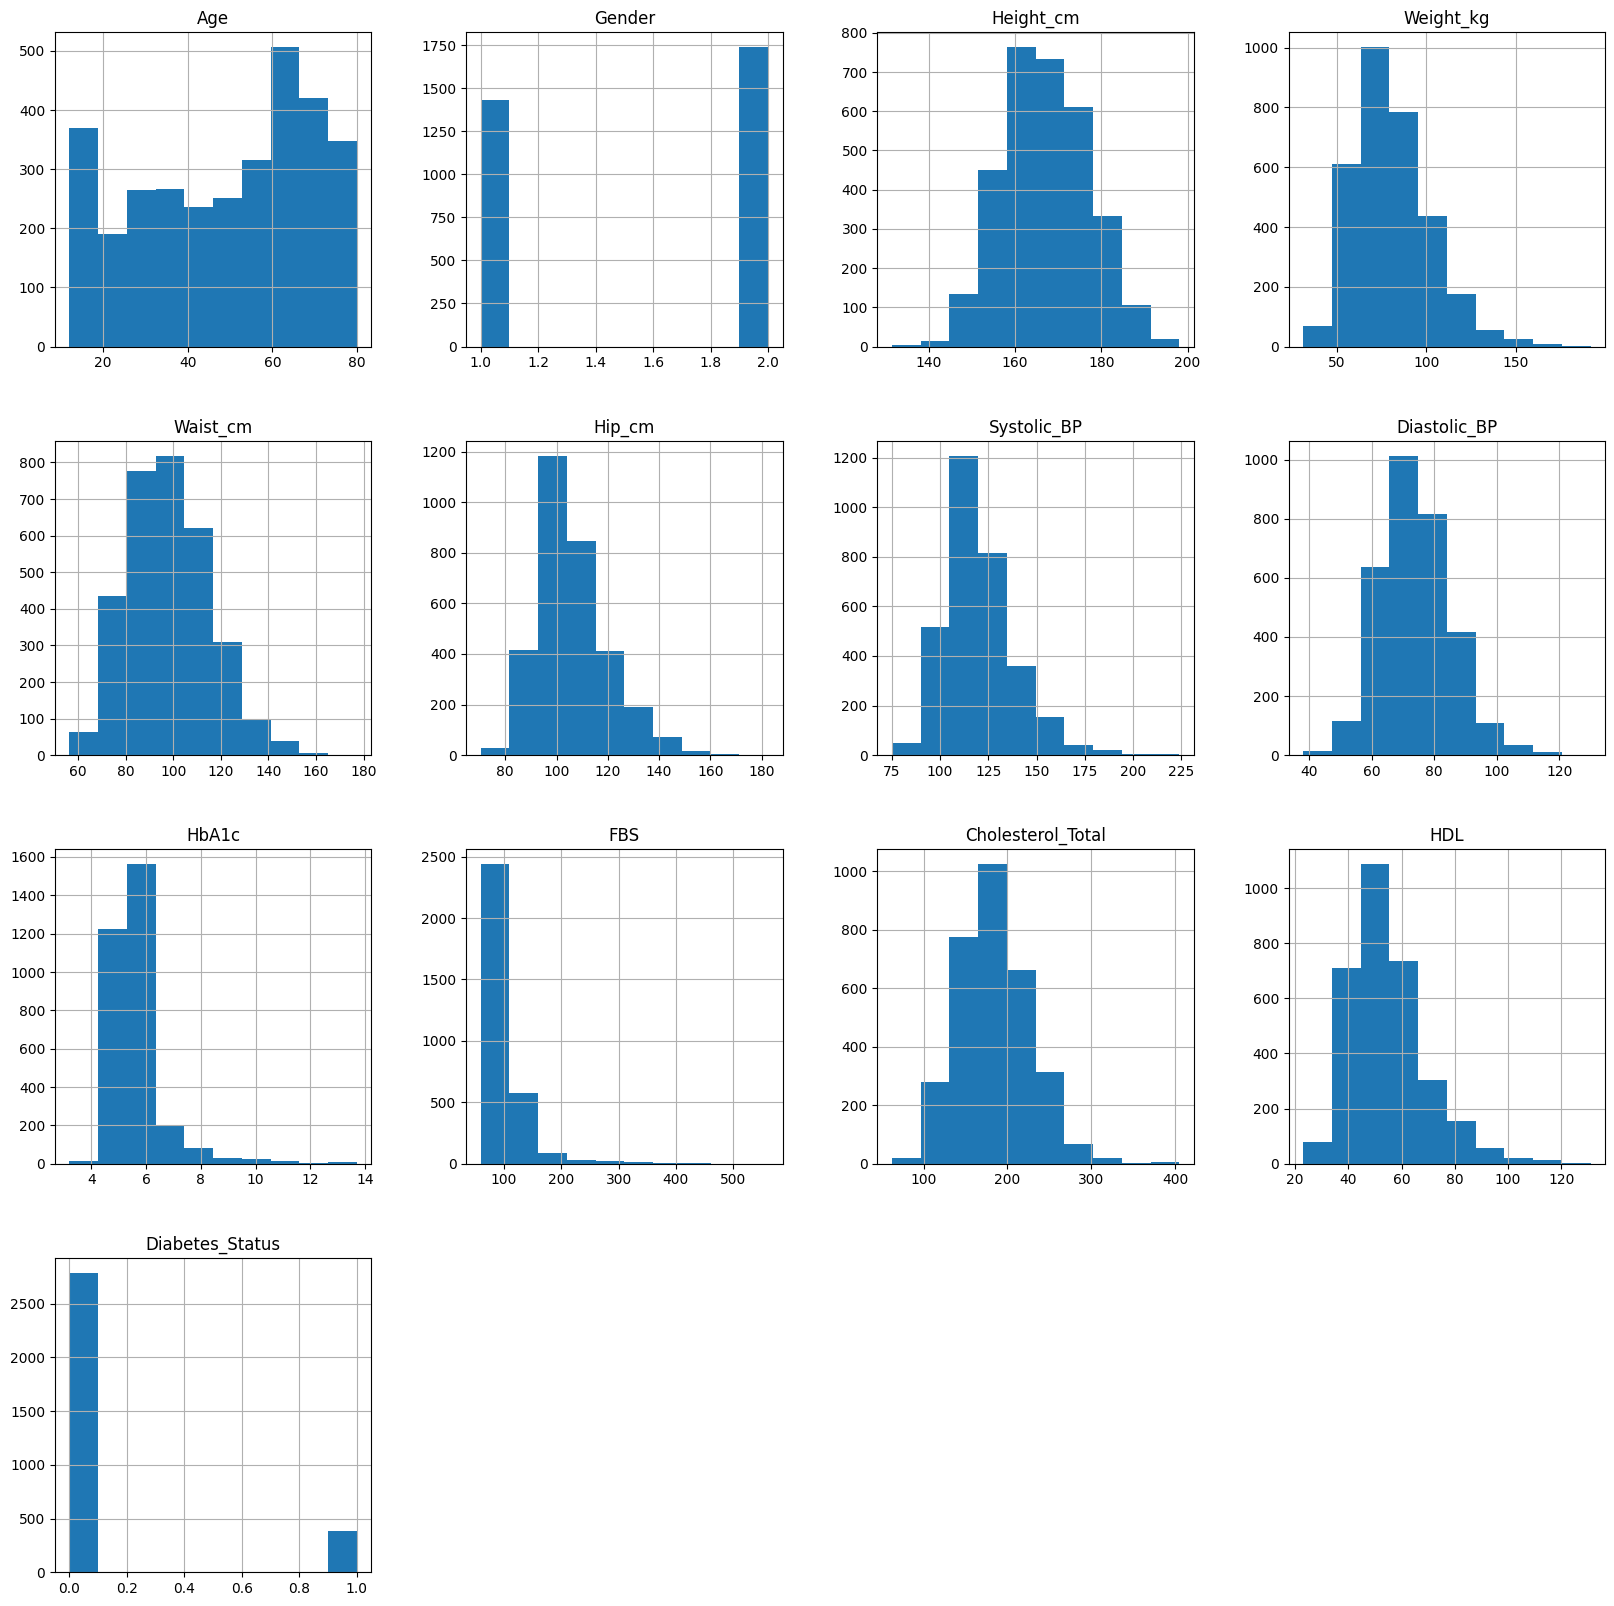

In [142]:
df = pd.read_csv("merged_data.csv")
df['Diabetes_Status'] = df['Diabetes_Status'].map({1:1, 2:0})
df = df.drop(columns=['SEQN'])
df.hist(figsize=(20,20))
from tabulate import tabulate

nulls = df.isnull().sum().reset_index()
nulls.columns = ['Column', 'Missing Values']
print(tabulate(nulls, headers='keys', tablefmt='psql'))


#CLEANING
df_clean = df.dropna()
df_clean = df_clean[(df_clean["Diabetes_Status"] != 3) & (df_clean["Diabetes_Status"] != 9)]
df_clean.hist(figsize=(20,20))
print(df_clean.isnull().sum())

<Axes: >

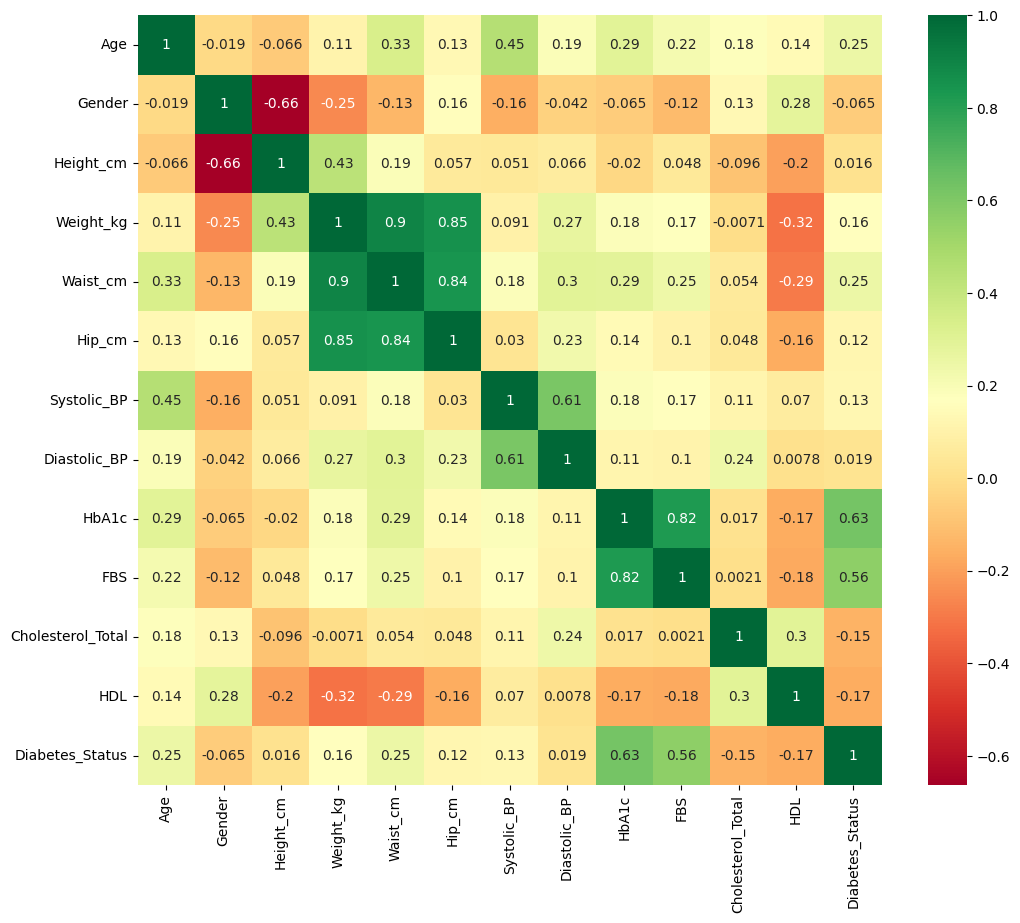

In [69]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_clean.corr(), annot=True, cmap='RdYlGn')

In [144]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)
print("Train ratio:\n", y_train.value_counts(normalize=True))
print("Valid ratio:\n", y_valid.value_counts(normalize=True))
print("Test ratio:\n", y_test.value_counts(normalize=True))


Train ratio:
 Diabetes_Status
0.0    0.879474
1.0    0.120526
Name: proportion, dtype: float64
Valid ratio:
 Diabetes_Status
0.0    0.879937
1.0    0.120063
Name: proportion, dtype: float64
Test ratio:
 Diabetes_Status
0.0    0.878549
1.0    0.121451
Name: proportion, dtype: float64


In [147]:
train = pd.DataFrame(X_train, columns=X.columns)
train["Diabetes_Status"] = y_train

valid = pd.DataFrame(X_valid, columns=X.columns)
valid["Diabetes_Status"] = y_valid

test = pd.DataFrame(X_test, columns=X.columns)
test["Diabetes_Status"] = y_test

In [121]:
train, valid, test = np.split(df_clean.sample(frac=1, random_state=42), [int(0.6*len(df_clean)), int(0.8*len(df_clean))])

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [122]:
train.head()

,Age,Gender,Height_cm,Weight_kg,Waist_cm,Hip_cm,Systolic_BP,Diastolic_BP,HbA1c,FBS,Cholesterol_Total,HDL,Diabetes_Status
3305,56.0,2.0,147.2,43.0,77.0,84.8,110.0,65.0,5.1,95.0,221.0,87.0,0.0
5183,59.0,1.0,173.3,138.7,141.4,139.8,126.0,71.0,6.6,123.0,203.0,35.0,0.0
10500,64.0,2.0,157.5,51.4,68.7,91.6,115.0,76.0,5.8,105.0,198.0,66.0,0.0
10800,59.0,2.0,166.4,86.3,103.9,118.0,114.0,82.0,6.3,116.0,252.0,80.0,0.0
9350,31.0,2.0,165.0,87.4,108.1,116.8,120.0,86.0,5.4,91.0,189.0,42.0,0.0


# **Raw Dataset Training**
all values are raw that contains NaN.

GENDER:
*   MALE: 1,
*   FEMALE: 2

DIABETES STATS:
*   YES: 1
*   NO: 0





In [9]:
print((df_clean['Diabetes_Status'].value_counts()))
print(df_clean.columns)

Diabetes_Status
2.0    2785
1.0     382
Name: count, dtype: int64
Index(['Age', 'Gender', 'Height_cm', 'Weight_kg', 'Waist_cm', 'Hip_cm',
       'Systolic_BP', 'Diastolic_BP', 'HbA1c', 'FBS', 'Cholesterol_Total',
       'HDL', 'Diabetes_Status'],
      dtype='object')


In [145]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import StandardScaler

def scale_dataset(dataframe, oversample=False):
	X = dataframe[dataframe.columns[:-1]].values
	y = dataframe[dataframe.columns[-1]].values

	scaler = StandardScaler()
	X = scaler.fit_transform(X)

	if oversample:
		ros = RandomOverSampler()
		X, y = ros.fit_resample(X, y)

	# puttig them side by side / hstack (horizontal stack) like combine
	# np is sensitive to 2D array, convert the y into 2D array
	data = np.hstack((X, np.reshape(y, (-1, 1))))


	return data, X, y

In [148]:
train, X_train, y_train = scale_dataset(train,oversample=True)
valid, X_valid, y_valid = scale_dataset(valid,oversample=False)
test, X_test, y_test = scale_dataset(test,oversample=False)

In [160]:
print(len(y_train[y_train==1]))
print(len(y_train[y_train==0]))


1671
1671


K-NEAREST NEIGHBORS

In [151]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=1)
knn_model.fit(X_train, y_train)

# PREDICTIONS
y_pred = knn_model.predict(X_test)


In [152]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.95      0.96      0.95       557
         1.0       0.67      0.64      0.65        77

    accuracy                           0.92       634
   macro avg       0.81      0.80      0.80       634
weighted avg       0.92      0.92      0.92       634



NAIVE BAYES

In [153]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model = nb_model.fit(X_train, y_train)

# PREDICTIONS
y_pred = nb_model.predict(X_test)

# CLASSIFICATION REPORT
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.98      0.93      0.95       557
         1.0       0.63      0.86      0.73        77

    accuracy                           0.92       634
   macro avg       0.81      0.89      0.84       634
weighted avg       0.94      0.92      0.93       634



LOGISTIC REGRESSION

In [154]:
from sklearn.linear_model import LogisticRegression

lg_model = LogisticRegression()
lg_model = lg_model.fit(X_train, y_train)

# PREDICTIONS
y_pred = lg_model.predict(X_test)

# CLASSIFICATION REPORT
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.99      0.91      0.94       557
         1.0       0.57      0.91      0.70        77

    accuracy                           0.91       634
   macro avg       0.78      0.91      0.82       634
weighted avg       0.94      0.91      0.92       634



SUPPORT VECTOR MACHINES

In [155]:
from sklearn.svm import SVC

# There are many params for this, tweak and try them
svm_model = SVC()
svm_model = svm_model.fit(X_train, y_train)

# PREDICTIONS
y_pred = svm_model.predict(X_test)

# CLASSIFICATION REPORT
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.98      0.90      0.94       557
         1.0       0.56      0.88      0.68        77

    accuracy                           0.90       634
   macro avg       0.77      0.89      0.81       634
weighted avg       0.93      0.90      0.91       634



RANDOM FORESTS

In [156]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(random_state=1)
forest_model.fit(X_train, y_train)

# PREDICTIONS
y_pred = forest_model.predict(X_test)

# CLASSIFICATION REPORT
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.96      0.97      0.97       557
         1.0       0.78      0.74      0.76        77

    accuracy                           0.94       634
   macro avg       0.87      0.86      0.86       634
weighted avg       0.94      0.94      0.94       634



# Feature Importance

Gini Importance

              Feature  Gini Importance
8               HbA1c         0.388754
9                 FBS         0.194397
0                 Age         0.094310
4            Waist_cm         0.057564
10  Cholesterol_Total         0.053299
11                HDL         0.041388
2           Height_cm         0.038546
3           Weight_kg         0.037479
6         Systolic_BP         0.032718
5              Hip_cm         0.030412
7        Diastolic_BP         0.026376
1              Gender         0.004757


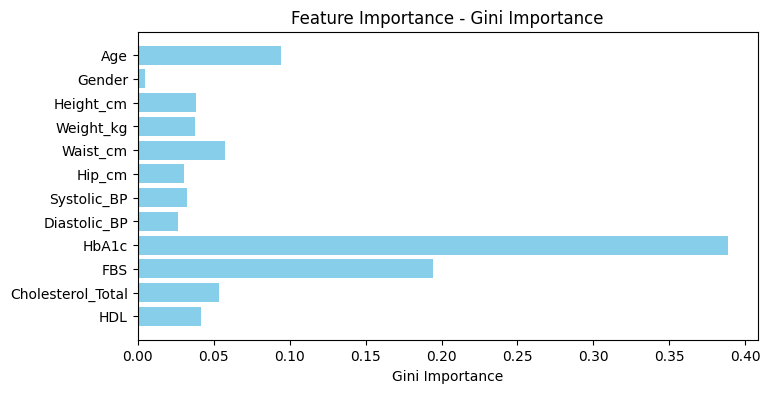

In [157]:
import shap
feature_names = df_clean.columns[:-1]
importances = forest_model.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Gini Importance': importances}).sort_values('Gini Importance', ascending=False)
print(feature_imp_df)

plt.figure(figsize=(8, 4))
plt.barh(feature_names, importances, color='skyblue')
plt.xlabel('Gini Importance')
plt.title('Feature Importance - Gini Importance')
plt.gca().invert_yaxis()  # Invert y-axis for better visualization
plt.show()

In [159]:
# new patient example (must follow same feature order used in training!)

new_patient = [[43, 1, 179.5, 86.9, 98.3, 102.9, 135, 98, 5.6, 113, 264, 45]]

print("Prediction:", forest_model.predict(new_patient))
print("Prediction:", forest_model.classes_)
print("Probabilities:", forest_model.predict_proba(new_patient))


Prediction: [0.]
Prediction: [0. 1.]
Probabilities: [[0.64 0.36]]


# Pipelines

In [91]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler

In [161]:
X = df_clean.drop(columns=["Diabetes_Status"])
y = df_clean["Diabetes_Status"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

new_patient = [[52, 1, 174.9, 84.4, 95.9, 96.4, 115, 72, 4.9, 97, 178, 31]]


In [166]:
print(y_train.value_counts())
print(X_test.head())

Diabetes_Status
0.0    1949
1.0     267
Name: count, dtype: int64
       Age  Gender  Height_cm  Weight_kg  Waist_cm  Hip_cm  Systolic_BP  \
6099  52.0     1.0      174.9       84.4      95.9    96.4        115.0   
5854  62.0     1.0      184.7       91.3      91.9   100.1        120.0   
6565  47.0     2.0      158.4       93.6     100.1   128.2        139.0   
778   33.0     2.0      147.4       87.8     117.0   123.6        111.0   
8336  80.0     2.0      153.7       61.4      96.6   103.2        168.0   

      Diastolic_BP  HbA1c    FBS  Cholesterol_Total   HDL  
6099          72.0    4.9   97.0              178.0  31.0  
5854          68.0    5.2   98.0              194.0  43.0  
6565         104.0    6.5  136.0              190.0  40.0  
778           87.0   12.4  305.0              212.0  39.0  
8336          79.0    5.5   95.0              250.0  69.0  


In [163]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(probability=True),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

In [169]:
results = {}

for name, model in models.items():
    print(f"\n🔹 Training {name}...")

    # Build pipeline
    pipe = Pipeline([
        ('scaler', StandardScaler()),          # scale data
        ('oversample', RandomOverSampler()),   # handle imbalance
        ('model', model)                       # chosen model
    ])

    # Fit on training data
    pipe.fit(X_train, y_train)

    # Evaluate on validation set
    y_pred = pipe.predict(X_valid)
    y_proba = pipe.predict_proba(X_valid)[:, 1]  # risk % (probability)

    auc = roc_auc_score(y_valid, y_proba)
    print(f"{name} ROC AUC: {auc:.3f}")
    print(classification_report(y_valid, y_pred))

    # Save pipeline + score
    results[name] = {"pipeline": pipe, "roc_auc": auc}

    # 🔹 Test on new patient
    new_patient = [[42, 2, 120, 80, 169.2, 121, 115, 72, 4.9, 97, 178, 31]]
    # must match X_train column order exactly!

    pred_class = pipe.predict(new_patient)[0]
    pred_proba = pipe.predict_proba(new_patient)[0]

    print(f"👉 New Patient Prediction ({name}): {pred_class}")
    print(f"👉 Probability of Diabetes: {pred_proba[0]:.3f} {pred_proba[1]:.3f}")



🔹 Training Logistic Regression...
Logistic Regression ROC AUC: 0.972
              precision    recall  f1-score   support

         0.0       0.99      0.89      0.94       418
         1.0       0.55      0.95      0.69        57

    accuracy                           0.90       475
   macro avg       0.77      0.92      0.82       475
weighted avg       0.94      0.90      0.91       475

👉 New Patient Prediction (Logistic Regression): 0.0
👉 Probability of Diabetes: 0.941 0.059

🔹 Training Random Forest...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Random Forest ROC AUC: 0.968
              precision    recall  f1-score   support

         0.0       0.97      0.98      0.97       418
         1.0       0.83      0.77      0.80        57

    accuracy                           0.95       475
   macro avg       0.90      0.88      0.89       475
weighted avg       0.95      0.95      0.95       475

👉 New Patient Prediction (Random Forest): 0.0
👉 Probability of Diabetes: 0.960 0.040

🔹 Training KNN...
KNN ROC AUC: 0.911
              precision    recall  f1-score   support

         0.0       0.98      0.90      0.94       418
         1.0       0.53      0.86      0.66        57

    accuracy                           0.89       475
   macro avg       0.76      0.88      0.80       475
weighted avg       0.93      0.89      0.90       475

👉 New Patient Prediction (KNN): 0.0
👉 Probability of Diabetes: 1.000 0.000

🔹 Training SVM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


SVM ROC AUC: 0.964
              precision    recall  f1-score   support

         0.0       0.98      0.93      0.95       418
         1.0       0.62      0.89      0.73        57

    accuracy                           0.92       475
   macro avg       0.80      0.91      0.84       475
weighted avg       0.94      0.92      0.93       475

👉 New Patient Prediction (SVM): 0.0
👉 Probability of Diabetes: 0.994 0.006

🔹 Training XGBoost...
XGBoost ROC AUC: 0.967
              precision    recall  f1-score   support

         0.0       0.97      0.97      0.97       418
         1.0       0.77      0.75      0.76        57

    accuracy                           0.94       475
   macro avg       0.87      0.86      0.86       475
weighted avg       0.94      0.94      0.94       475

👉 New Patient Prediction (XGBoost): 0
👉 Probability of Diabetes: 1.000 0.000


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [16:19:43] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


kNN pipe

In [ ]:
knn_pipe = Pipeline([
    ('scaler', )
])